<p align="center">
    <span style="font-size:2.5em; font-weight:bold;">
        eFleetPlan - Optimal infrastructure and fleet operation of electric LCV
    </span>
</p>

<p align="center">
    <span style="font-size:1.5em; font-weight:bold;">
        Carolina Gil Ribeiro, Jagruti Thakur
    </span>
</p>

## 0. Importing dependencies

In [1]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory 
import pandas as pd
import numpy as np
import xlsxwriter as xl
import matplotlib.pyplot as plt
import os
from glob import glob
from matplotlib import rcParams
from datetime import datetime
from pyomo.opt.results import SolverStatus
import datetime as dt
import math
from typing import Literal
import time
from matplotlib.ticker import MaxNLocator

import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


from src.efleetplan._2_optimisation.optimisation import optimisation, save_results
from src.efleetplan._2_optimisation.optimisation_graphs import graph_vehicles, plot_summary_table, process_folder, graph_number_of_chargers_by_schedules, graph_chargingpower, graph_powerbytype

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
notebook_dir = os.getcwd()

# 2. Charging Infrastructure co-optimisation Module

## 2.1 optimisation parameters configurations

In [2]:
# environment optimisation arguments - adjust settings if necessary

# Define schedule name and number as variables
schedule_name = "schedule_4"
schedule_number = 4
opt_config = {# settings for the optimisation function              
    "opt_start_date": "2023-01-01 00:00:00",  # New schedule, start date
    "opt_end_date": "2023-01-31 23:00:00",    # New schedule, end date
    "freq": "h",                              # 'h' means hourly frequency.

    "Schedule name": schedule_name,           # Name of the schedule - used to create input and output folders
    "EVs": 30,                               # Number of electric vehicles in the fleet

    # Input and output folders
    "output_folder": os.path.join(project_root, 'data', 'Output', schedule_name),
    "input_folder": os.path.join(project_root, 'data', 'Input'),

    # CSV file with electricity prices (the example is for SE3 in Stockholm, Sweden)
    "electricity_price_grid": pd.read_csv(os.path.join(project_root, 'data', 'Input', 'SE3_el_prices_2023_modified.csv')),

    # Load the data for the vehicles created in the schedule generator module
    ## Energy consumption file
    "En_consumption": pd.read_csv(os.path.join(project_root, 'data', 'Output', schedule_name, f'{schedule_number}_all_vehicles_Consumption_rate_corrected.csv')),
    ## Distance travel per vehicles and per hour file
    "Ev_distance": pd.read_csv(os.path.join(project_root, 'data', 'Output', schedule_name, f'{schedule_number}_all_vehicles_Distance_km.csv')),
    ## Vehicles availability to charge at the distribution terminal
    "Ev_availability_file": pd.read_csv(os.path.join(project_root, 'data', 'Output', schedule_name, f'{schedule_number}_all_vehicles_ChargingStation.csv')),
    ## Battery capacity - important when the fleet has more than one type of vehicle
    "Battery_Limitation": pd.read_csv(os.path.join(project_root, 'data', 'Output', schedule_name, f'{schedule_number}_all_vehicles_Battery_Capacity_kWh.csv')),

    ## Vehicle battery power - important when the fleet has more than one type of vehicle                                         
    "PowerRate_Limitation": pd.read_csv(os.path.join(project_root, 'data', 'Output', schedule_name, f'{schedule_number}_all_vehicles_PowerRating_kW.csv')),

    "MIPGap": 0.25                            # MIP optimality gap
}

## 2.2. Cost and power configuration

In the cost and power configurations above, it is possible to change the values of different paramenters, related to cost of infrastructure, energy subscription rates, route charging rates and battery power and losses.

In [3]:
power_config = {
    "Charging_losses": 0.964,  # Charging efficiency
    "Battery_Maximum Limit": 0.8,  # Maximum battery limit
    "Battery_Minimum Limit": 0.2,   # Minimum battery limit
    "Accumulated_Cycle_Capacity": 3500,  # Total energy throughput (in kWh) that the battery can handle
    "Charger_Power" : {'s': 7.4, 'Route': 150, 'f1': 50, 'f2': 150, 'f3': 350},  # Charging power of each type of charger
}

In [4]:
cost_config = {"Infrastructure_life": 20, #lifetime or ownership time of the charging infrastructure
               "Infrastructure_cost": {'s': 32000 + 29000, # Slow charger cost
                                       'f1': 294000 + 472000, # Fast charger 50 kw cost
                                       'f2': 778000 + 644000, # Fast charger 150 kw cost
                                       'f3': 1451000 + 1202000}, # Fast charger 350 kw cost
               "maintenance_cost" : {'s': 5000, 'f1': 40000, 'f2': 120000, 'f3': 240000}, # Maintenance cost per type of charger
               "Infrastructure_subscription" : 50,  # SEK/day,
               "Price_FixedrateDT" : 0.0331,
               "Demand_rate" : 1352,
               "Price_FixedrateRoute" : 8.90,
               "Discount_rate": 0.05
               }

## 2.3 Run optimisation

In [5]:
# Call the optimisation function
m, Price, EV_availability, Distance_km = optimisation(opt_config, cost_config, power_config)

Number of days: 31
=== SOLVER CONFIGURATION ===
  MIPGap: 0.25
  ScaleFlag: 2
  LogFile: gurobi_log.txt
  Threads: 8
  Seed: 42
  Method: 2
  Presolve: 2
  NodeMethod: 3
  Cuts: -1
  Heuristics: 0.3
  MIPFocus: 3
        5.45 seconds required to write file
        5.45 seconds required for presolve
Set parameter Username
Set parameter LicenseID to value 2678500
Academic license - for non-commercial use only - expires 2026-06-16
Read LP format model from file C:\Users\mcgr2\AppData\Local\Temp\tmpzg_475u7.pyomo.lp
Reading time = 0.68 seconds
x1: 281784 rows, 357307 columns, 795114 nonzeros
Set parameter MIPGap to value 0.25
Set parameter ScaleFlag to value 2
Set parameter LogFile to value "gurobi_log.txt"
Set parameter Threads to value 8
Set parameter Seed to value 42
Set parameter Method to value 2
Set parameter Presolve to value 2
Set parameter NodeMethod to value 3
Set parameter Cuts to value -1
Set parameter Heuristics to value 0.3
Set parameter MIPFocus to value 3
Gurobi Optimizer v

### Saving results

In [6]:
# Ensure the output directory exists before saving results
results_folder = os.path.join(project_root, 'data', 'Output', f'{schedule_name}', 'Results')
os.makedirs(results_folder, exist_ok=True)

csv_file_pathA = os.path.join(results_folder, f'{schedule_number}_Main_variables_results.csv')
csv_file_pathB = os.path.join(results_folder, f'{schedule_number}_results_summary.csv')
csv_file_pathC = os.path.join(results_folder, f'{schedule_number}_results_per_EV.csv')
csv_file_pathD = os.path.join(results_folder, f'{schedule_number}_results_per_EV_descriptive.csv')

In [7]:
save_results(m, Price, EV_availability, Distance_km, csv_file_pathA, csv_file_pathB, csv_file_pathC, csv_file_pathD, cost_config, power_config)

✅ Results saved successfully as CSV!


## 2.4. Post-processing and visualisation

c:\Users\mcgr2\Optimisation\eFleetPlan\src\efleetplan\_2_optimisation\optimisation_graphs.py:56: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table_df = df_other.pivot_table(index='Category', columns='Description', values='Value', sort=False)
c:\Users\mcgr2\Optimisation\eFleetPlan\src\efleetplan\_2_optimisation\optimisation_graphs.py:57: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table_dt = df_dt.pivot_table(index='Category', columns='Description', values='Value', sort=False)


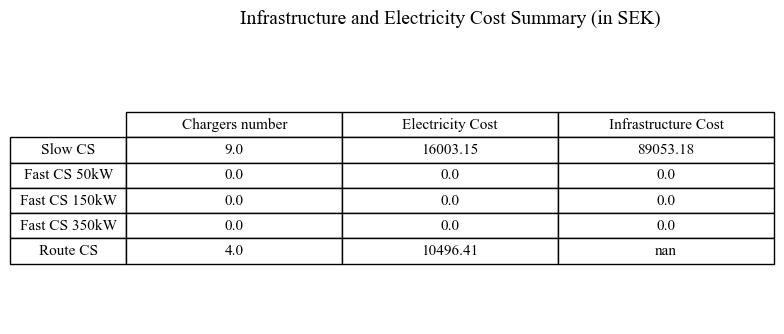

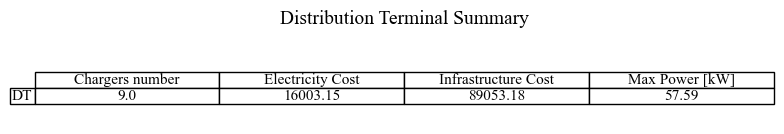

In [8]:
# Set the path to your folder
file_pattern_mean = os.path.join(project_root, 'data', 'Output', f'{schedule_name}', 'Results', '*_results_summary.csv')

# Use glob to find the actual file
matched_files = glob(file_pattern_mean)
if not matched_files:
    raise FileNotFoundError(f"No file matches the pattern: {file_pattern_mean}")
file_path = matched_files[0]


plot_summary_table(file_path)

### Create maximum and average files

In [9]:
# Set the path to your folder
folder_path = os.path.join(project_root, 'data', 'Output', f'{schedule_name}', 'Results')

# Find all files with the pattern *_hourly_averages.csv
filename_pattern = os.path.join(folder_path, '*_Main_variables_results.csv')

process_folder(folder_path, filename_pattern)

Processed 4_Main_variables_results.csv in c:\Users\mcgr2\Optimisation\eFleetPlan\data\Output\schedule_4\Results.


4


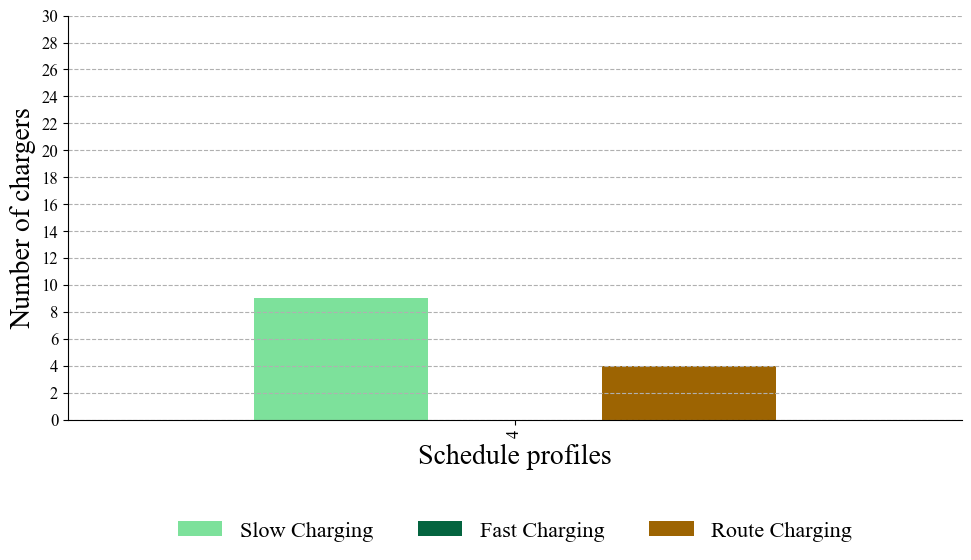

<Figure size 640x480 with 0 Axes>

In [10]:
# Set the path to your folder
folder_path = os.path.join(project_root, 'data', 'Output', f'{schedule_name}', 'Results')
file_pattern_max = os.path.join(project_root, 'data', 'Output', f'{schedule_name}', 'Results', '*_max_variable_per_hour.csv')
files_hourly_max = glob(file_pattern_max)

graph1 = graph_number_of_chargers_by_schedules(folder_path, files_hourly_max)

### Graph 2 - Average charging power and average price of electricity

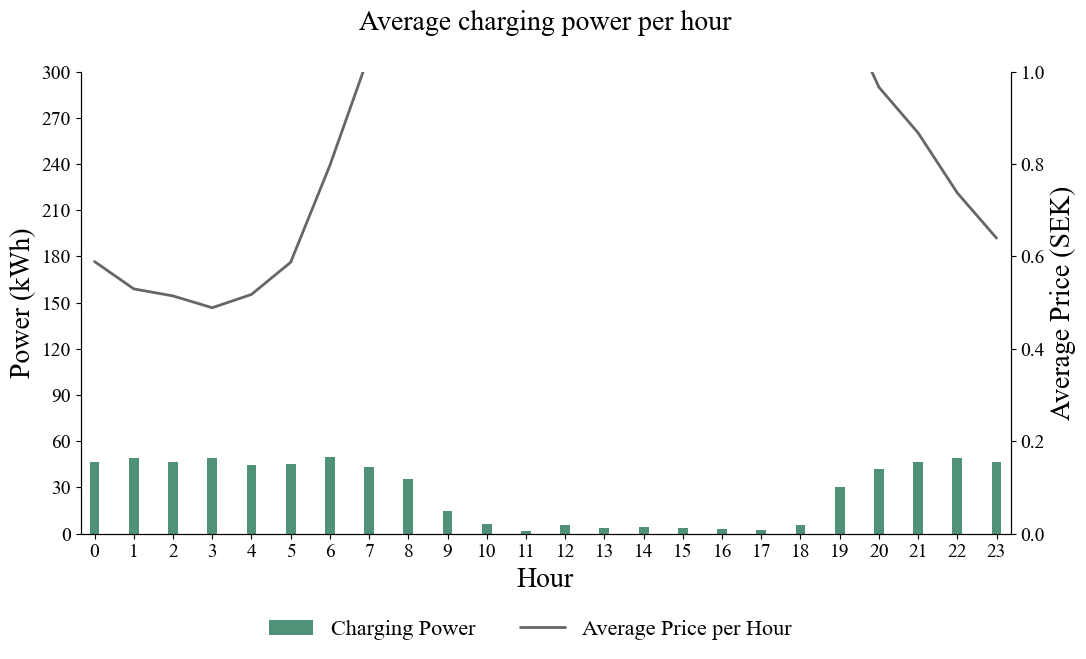

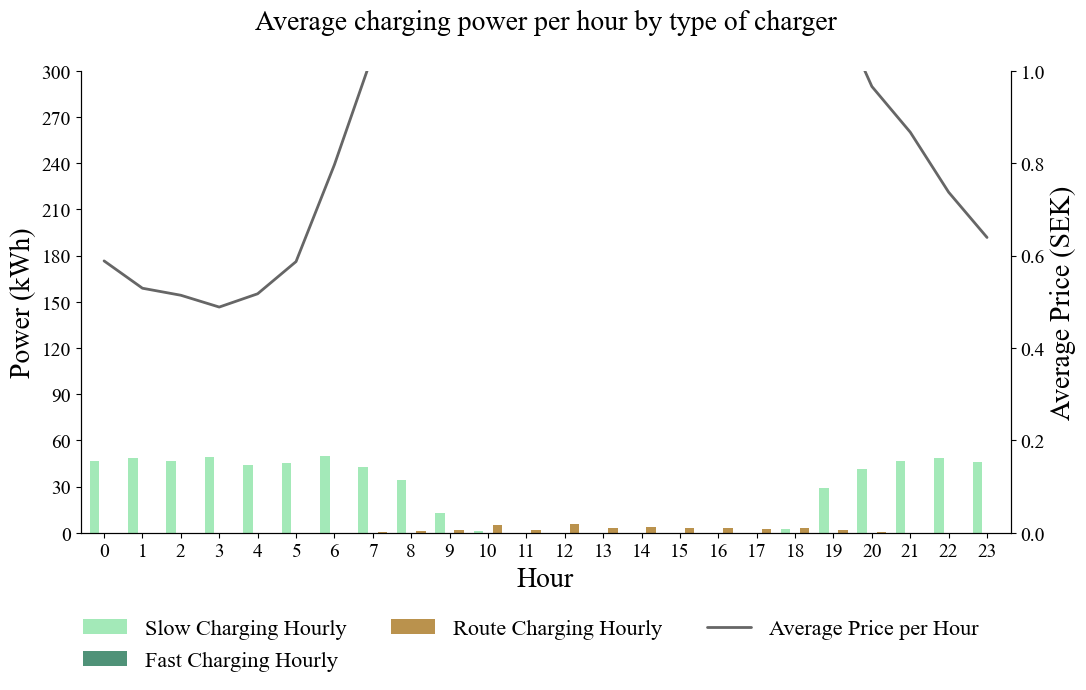

(<Axes: xlabel='Hour', ylabel='Power (kWh)'>,
 <Axes: title={'center': 'Average charging power per hour by type of charger'}, ylabel='Average Price (SEK)'>)

In [11]:
# Set the path to your folder
file_pattern_mean = os.path.join(project_root, 'data', 'Output', f'{schedule_name}', 'Results', '*_avg_variable_per_hour.csv')
# Use glob to find the actual file

matched_files = glob(file_pattern_mean)
if not matched_files:
    raise FileNotFoundError(f"No file matches the pattern: {file_pattern_mean}")
file_path = matched_files[0]
folder_path = os.path.join(project_root, 'data', 'Output', f'{schedule_name}', 'Results')

graph_chargingpower(file_path, folder_path)

graph_powerbytype(file_path, folder_path)

### Graph 3 - Charging, discharging power and SOC

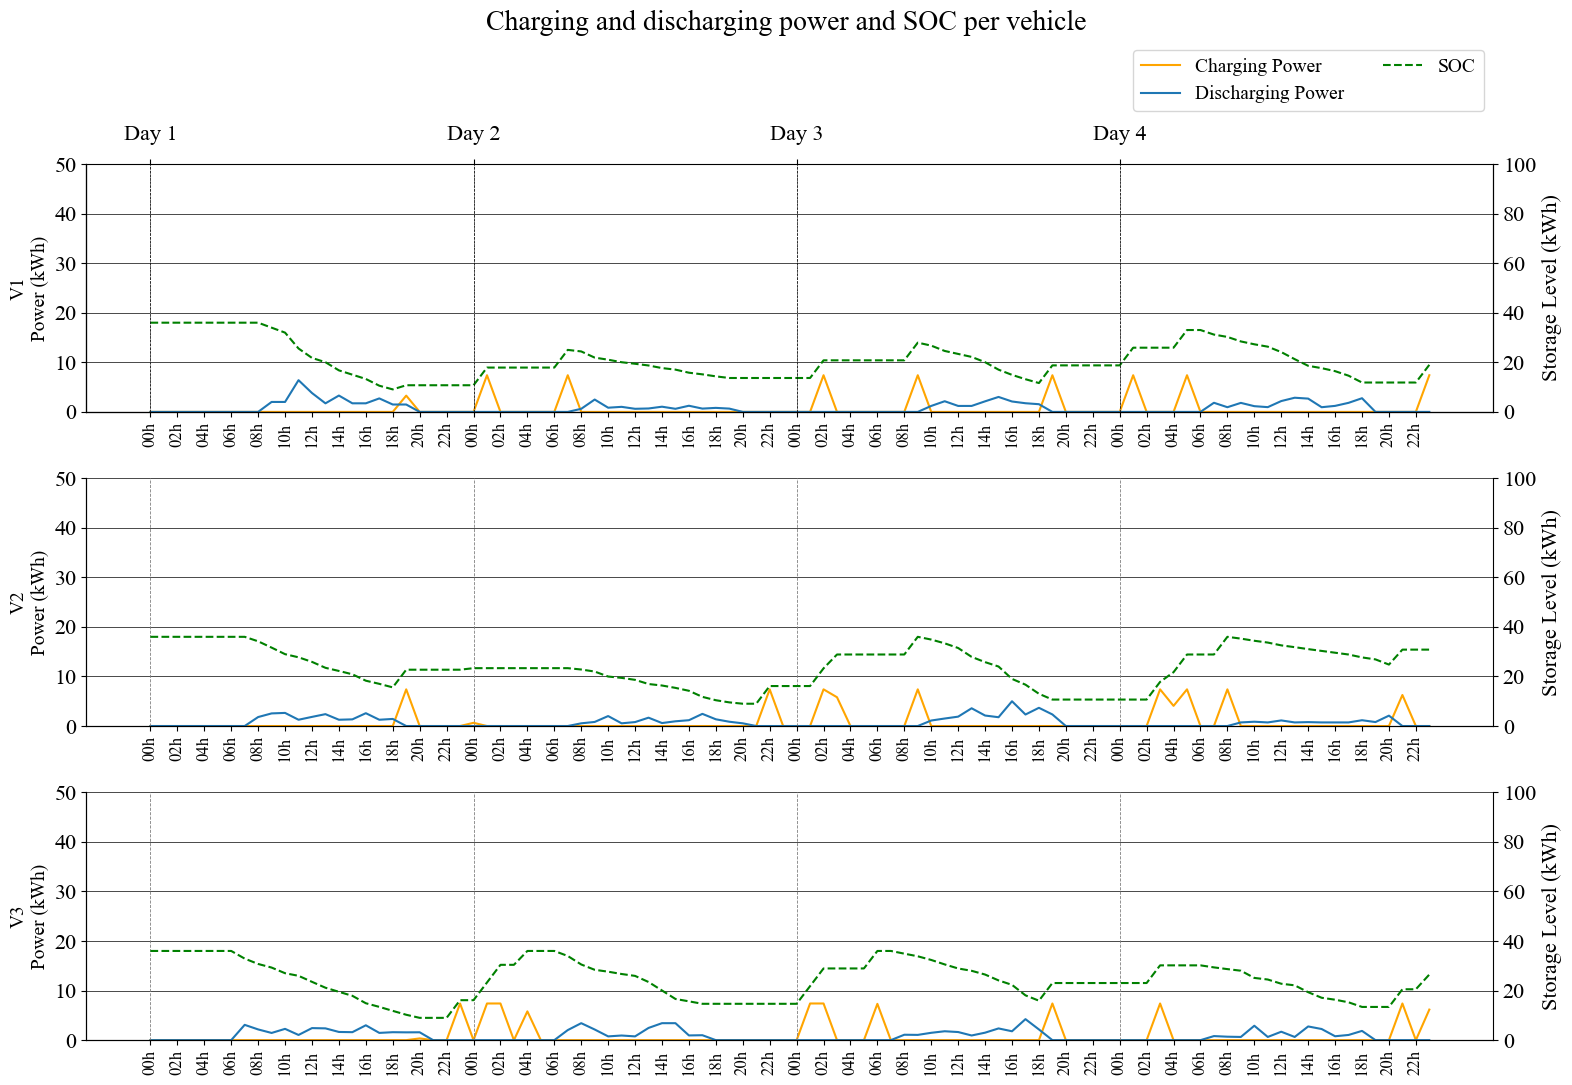

In [12]:
# Set the path to your folder
file_path = csv_file_pathD

# Set the number of vehicles for the graph
n_vehicles = 3
# Set the number of days for the graph
n_days = 4

graph_vehicles(folder_path, file_path, n_days, n_vehicles)